# Cyclistic Bike Share Analysis
Google Data Analytics Capstone Project

## Business Task

Analyze how casual riders and annual members use Cyclistic bikes differently.

In [ ]:
pip install pandas matplotlib seaborn jupyter numpy

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob


In [6]:
path = "../data/*.csv"
files = glob.glob(path)

print(files)

['../data\\Divvy_Trips_2019_Q1.csv', '../data\\Divvy_Trips_2019_Q2.csv', '../data\\Divvy_Trips_2019_Q3.csv', '../data\\Divvy_Trips_2019_Q4.csv']


In [7]:
df_list = []

for file in files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

In [8]:
#combine all data
df = pd.concat(df_list, ignore_index=True)

In [ ]:
#preview data
df.head()

,trip_id,start_time,end_time,bikeid,tripduration,from_station_id,from_station_name,to_station_id,to_station_name,usertype,...,01 - Rental Details Local End Time,01 - Rental Details Bike ID,01 - Rental Details Duration In Seconds Uncapped,03 - Rental Start Station ID,03 - Rental Start Station Name,02 - Rental End Station ID,02 - Rental End Station Name,User Type,Member Gender,05 - Member Details Member Birthday Year
0,21742443.0,2019-01-01 00:04:37,2019-01-01 00:11:07,2167.0,390.0,199.0,Wabash Ave & Grand Ave,84.0,Milwaukee Ave & Grand Ave,Subscriber,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,21742444.0,2019-01-01 00:08:13,2019-01-01 00:15:34,4386.0,441.0,44.0,State St & Randolph St,624.0,Dearborn St & Van Buren St (*),Subscriber,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21742445.0,2019-01-01 00:13:23,2019-01-01 00:27:12,1524.0,829.0,15.0,Racine Ave & 18th St,644.0,Western Ave & Fillmore St (*),Subscriber,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,21742446.0,2019-01-01 00:13:45,2019-01-01 00:43:28,252.0,"1,783.0",123.0,California Ave & Milwaukee Ave,176.0,Clark St & Elm St,Subscriber,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,21742447.0,2019-01-01 00:14:52,2019-01-01 00:20:56,1170.0,364.0,173.0,Mies van der Rohe Way & Chicago Ave,35.0,Streeter Dr & Grand Ave,Subscriber,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.shape

(3818004, 24)

In [12]:
df.columns

Index(['trip_id', 'start_time', 'end_time', 'bikeid', 'tripduration',
       'from_station_id', 'from_station_name', 'to_station_id',
       'to_station_name', 'usertype', 'gender', 'birthyear',
       '01 - Rental Details Rental ID', '01 - Rental Details Local Start Time',
       '01 - Rental Details Local End Time', '01 - Rental Details Bike ID',
       '01 - Rental Details Duration In Seconds Uncapped',
       '03 - Rental Start Station ID', '03 - Rental Start Station Name',
       '02 - Rental End Station ID', '02 - Rental End Station Name',
       'User Type', 'Member Gender',
       '05 - Member Details Member Birthday Year'],
      dtype='str')

In [13]:
#convert text to date time
df["start_time"] = pd.to_datetime(df["start_time"])
df["end_time"] = pd.to_datetime(df["end_time"])

In [14]:
#calculate ride length in mins
df["ride_length"] = (df["end_time"] - df["start_time"]).dt.total_seconds() / 60

In [15]:
#remove errors
df = df[df["ride_length"] > 0]

In [16]:
#analyze weekday vs weekend
df["day_of_week"] = df["start_time"].dt.day_name()

In [17]:
df["hour"] = df["start_time"].dt.hour

In [18]:
#data check
df[["usertype","ride_length","day_of_week","hour"]].head()

,usertype,ride_length,day_of_week,hour
0,Subscriber,6.500000,Tuesday,0
1,Subscriber,7.350000,Tuesday,0
2,Subscriber,13.816667,Tuesday,0
3,Subscriber,29.716667,Tuesday,0
4,Subscriber,6.066667,Tuesday,0


In [19]:
df = df[[
    "trip_id",
    "start_time",
    "end_time",
    "bikeid",
    "tripduration",
    "from_station_id",
    "from_station_name",
    "to_station_id",
    "to_station_name",
    "usertype",
    "gender",
    "birthyear",
    "ride_length",
    "day_of_week",
    "hour"
]]

In [20]:
df = df.drop(columns=["gender","birthyear"])

In [21]:
df.isnull().sum()

trip_id              0
start_time           0
end_time             0
bikeid               0
tripduration         0
from_station_id      0
from_station_name    0
to_station_id        0
to_station_name      0
usertype             0
ride_length          0
day_of_week          0
hour                 0
dtype: int64

In [22]:
df.head()

,trip_id,start_time,end_time,bikeid,tripduration,from_station_id,from_station_name,to_station_id,to_station_name,usertype,ride_length,day_of_week,hour
0,21742443.0,2019-01-01 00:04:37,2019-01-01 00:11:07,2167.0,390.0,199.0,Wabash Ave & Grand Ave,84.0,Milwaukee Ave & Grand Ave,Subscriber,6.500000,Tuesday,0
1,21742444.0,2019-01-01 00:08:13,2019-01-01 00:15:34,4386.0,441.0,44.0,State St & Randolph St,624.0,Dearborn St & Van Buren St (*),Subscriber,7.350000,Tuesday,0
2,21742445.0,2019-01-01 00:13:23,2019-01-01 00:27:12,1524.0,829.0,15.0,Racine Ave & 18th St,644.0,Western Ave & Fillmore St (*),Subscriber,13.816667,Tuesday,0
3,21742446.0,2019-01-01 00:13:45,2019-01-01 00:43:28,252.0,"1,783.0",123.0,California Ave & Milwaukee Ave,176.0,Clark St & Elm St,Subscriber,29.716667,Tuesday,0
4,21742447.0,2019-01-01 00:14:52,2019-01-01 00:20:56,1170.0,364.0,173.0,Mies van der Rohe Way & Chicago Ave,35.0,Streeter Dr & Grand Ave,Subscriber,6.066667,Tuesday,0


In [23]:
df["usertype"].value_counts()

usertype
Subscriber    2088783
Customer       621045
Name: count, dtype: int64

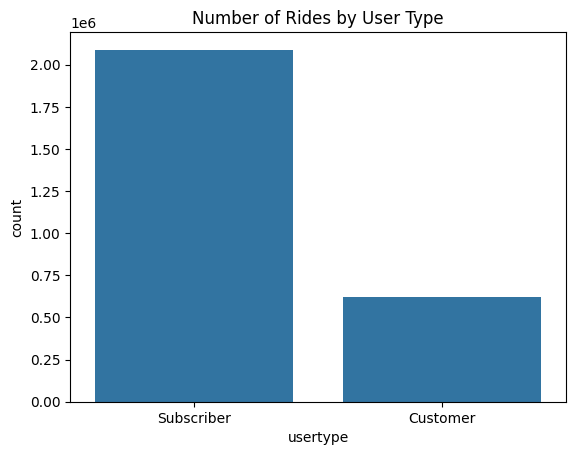

In [24]:
sns.countplot(data=df, x="usertype")
plt.title("Number of Rides by User Type")
plt.show()

Subscribers take significantly more rides than casual customers.
This suggests that annual members rely on Cyclistic bikes for regular transportation,
while casual riders may use them occasionally.

In [25]:
df["usertype"].value_counts()

usertype
Subscriber    2088783
Customer       621045
Name: count, dtype: int64

In [26]:
#Average Ride Length by User Type
df.groupby("usertype")["ride_length"].mean()

usertype
Customer      60.571686
Subscriber    14.441793
Name: ride_length, dtype: float64

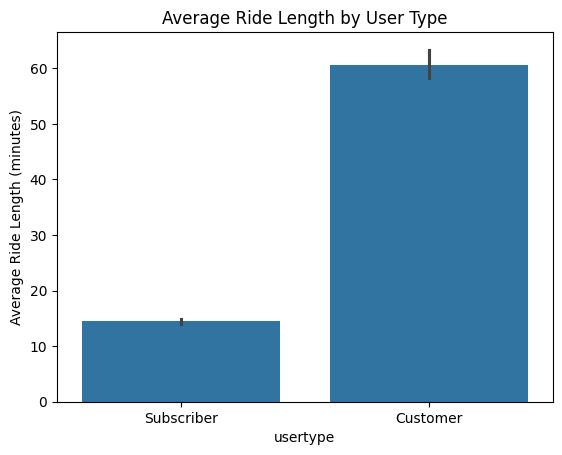

In [27]:
sns.barplot(data=df, x="usertype", y="ride_length")
plt.title("Average Ride Length by User Type")
plt.ylabel("Average Ride Length (minutes)")
plt.show()

### Insight

Casual riders take significantly longer rides than subscribers.
This suggests that casual riders use Cyclistic bikes primarily
for leisure or tourism, while subscribers likely use them for
shorter commuting trips.

In [28]:
#analyze weekly behaviour
df.groupby(["day_of_week","usertype"])["ride_length"].mean()

day_of_week  usertype  
Friday       Customer      65.698464
             Subscriber    13.949499
Monday       Customer      58.299254
             Subscriber    14.340835
Saturday     Customer      55.559927
             Subscriber    16.740899
Sunday       Customer      59.808259
             Subscriber    15.271295
Thursday     Customer      63.657813
             Subscriber    13.803298
Tuesday      Customer      61.123890
             Subscriber    14.498473
Wednesday    Customer      64.717353
             Subscriber    13.815971
Name: ride_length, dtype: float64

In [29]:
df.groupby("usertype")["ride_length"].mean()

usertype
Customer      60.571686
Subscriber    14.441793
Name: ride_length, dtype: float64

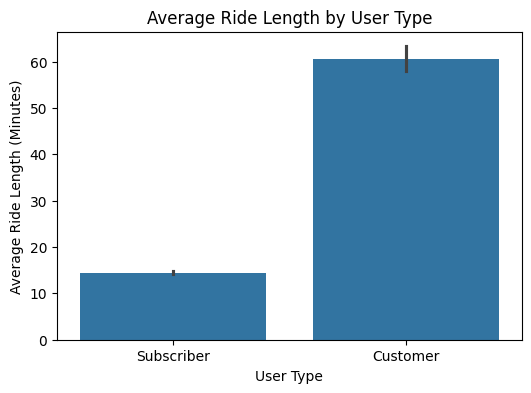

In [30]:
plt.figure(figsize=(6,4))

sns.barplot(data=df, x="usertype", y="ride_length")

plt.title("Average Ride Length by User Type")
plt.xlabel("User Type")
plt.ylabel("Average Ride Length (Minutes)")

plt.show()

### Insight

Casual riders take significantly longer rides compared to subscribers.
The average ride length for customers is about 60 minutes, while subscribers
ride for about 14 minutes on average.

This suggests casual riders primarily use Cyclistic bikes for leisure
activities, while subscribers use them for shorter commuting trips.

In [31]:
rides_by_day = df.groupby(["day_of_week","usertype"]).size().reset_index(name="rides")
rides_by_day

,day_of_week,usertype,rides
0,Friday,Customer,84533
1,Friday,Subscriber,321562
2,Monday,Customer,73912
3,Monday,Subscriber,329914
4,Saturday,Customer,143225
5,Saturday,Subscriber,201279
6,Sunday,Customer,114841
7,Sunday,Subscriber,180584
8,Thursday,Customer,76601
9,Thursday,Subscriber,348966


In [33]:
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

rides_by_day["day_of_week"] = pd.Categorical(
    rides_by_day["day_of_week"],
    categories=order,
    ordered=True
)

rides_by_day = rides_by_day.sort_values("day_of_week")

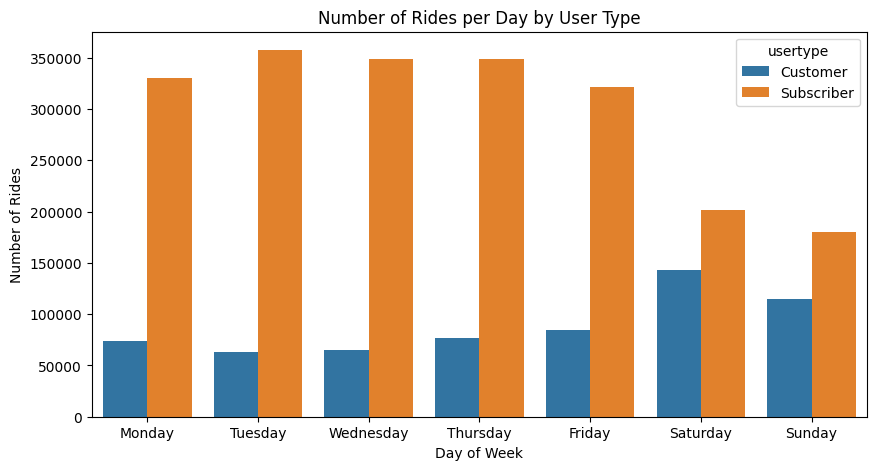

In [34]:
plt.figure(figsize=(10,5))

sns.barplot(data=rides_by_day, x="day_of_week", y="rides", hue="usertype")

plt.title("Number of Rides per Day by User Type")
plt.xlabel("Day of Week")
plt.ylabel("Number of Rides")

plt.show()

### Weekly Riding Patterns

Subscribers ride significantly more during weekdays, suggesting that they primarily use bikes for commuting and daily transportation.

Casual riders show increased activity on weekends, indicating that they are more likely using the bikes for leisure, tourism, or recreational trips.

This behavioral difference suggests that marketing strategies aimed at converting casual riders into members could focus on promoting membership benefits for frequent commuting.

In [35]:
rides_by_hour = df.groupby(["hour","usertype"]).size().reset_index(name="rides")

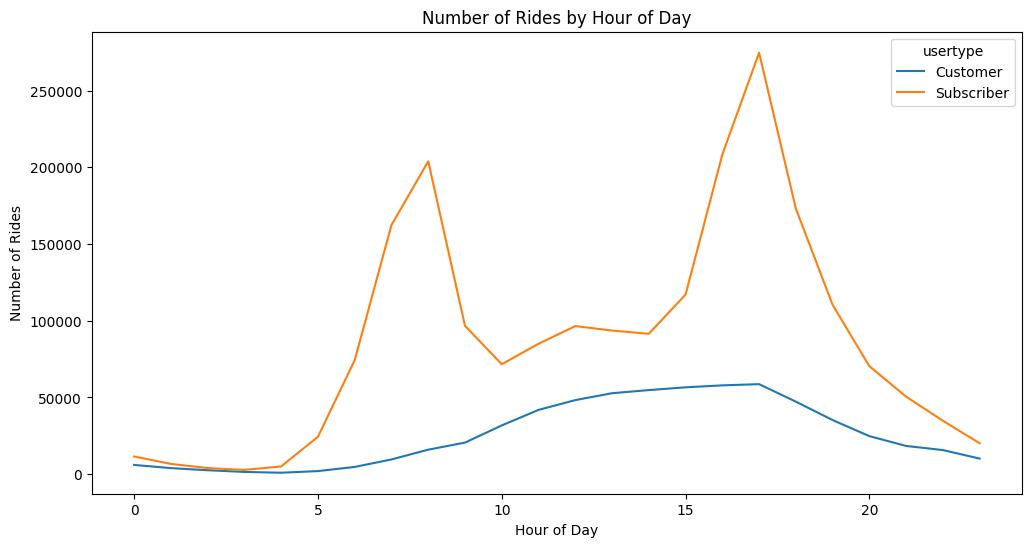

In [36]:
plt.figure(figsize=(12,6))

sns.lineplot(data=rides_by_hour, x="hour", y="rides", hue="usertype")

plt.title("Number of Rides by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")

plt.show()

### Hourly Riding Patterns

Subscribers show clear commuting behavior with two major peaks around
8 AM and 5–6 PM, corresponding to typical work commute hours.

Casual riders show a more gradual increase in rides throughout the day,
with higher activity during midday and afternoon hours.

This suggests that subscribers primarily use Cyclistic bikes for
transportation to and from work, while casual riders use them more
for leisure and recreational trips.

## Recommendations

Based on the analysis, Cyclistic should focus on converting casual riders into annual members.

1. Promote commuter benefits of membership such as cost savings for frequent rides.

2. Offer targeted weekend promotions encouraging casual riders to try weekday commuting with Cyclistic bikes.

3. Provide discounted membership trials for casual riders who frequently take long leisure rides.

4. Highlight convenience and reliability of Cyclistic bikes as a transportation option for daily commuting.